In [34]:
import pandas as pd

In [35]:
df = pd.read_csv("data/college_student_placement_dataset.csv")
print(df.head())


  College_ID   IQ  Prev_Sem_Result  CGPA  Academic_Performance  \
0    CLG0030  107             6.61  6.28                     8   
1    CLG0061   97             5.52  5.37                     8   
2    CLG0036  109             5.36  5.83                     9   
3    CLG0055  122             5.47  5.75                     6   
4    CLG0004   96             7.91  7.69                     7   

  Internship_Experience  Extra_Curricular_Score  Communication_Skills  \
0                    No                       8                     8   
1                    No                       7                     8   
2                    No                       3                     1   
3                   Yes                       1                     6   
4                    No                       8                    10   

   Projects_Completed Placement  
0                   4        No  
1                   0        No  
2                   1        No  
3                   1       

In [36]:
print(df.shape)

(10000, 10)


In [37]:
print(df.columns)

Index(['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='object')


In [38]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   College_ID              10000 non-null  object 
 1   IQ                      10000 non-null  int64  
 2   Prev_Sem_Result         10000 non-null  float64
 3   CGPA                    10000 non-null  float64
 4   Academic_Performance    10000 non-null  int64  
 5   Internship_Experience   10000 non-null  object 
 6   Extra_Curricular_Score  10000 non-null  int64  
 7   Communication_Skills    10000 non-null  int64  
 8   Projects_Completed      10000 non-null  int64  
 9   Placement               10000 non-null  object 
dtypes: float64(2), int64(5), object(3)
memory usage: 781.4+ KB
None


In [39]:
print(df.isnull().sum())

College_ID                0
IQ                        0
Prev_Sem_Result           0
CGPA                      0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
Placement                 0
dtype: int64


In [40]:
print("\nPlacement Count:")
print(df["Placement"].value_counts())


Placement Count:
Placement
No     8341
Yes    1659
Name: count, dtype: int64


In [41]:
placement_percentage = (df["Placement"].value_counts(normalize=True)*100)
print("\nPlacement Percentage:")
print(placement_percentage)


Placement Percentage:
Placement
No     83.41
Yes    16.59
Name: proportion, dtype: float64


In [42]:
average_cgpa = df["CGPA"].mean()

print("\nAverage CGPA:")
print(average_cgpa)


Average CGPA:
7.532379


In [43]:
average_cgpa_placement = df.groupby("Placement")["CGPA"].mean()

print("\nAverage CGPA by Placement:")
print(average_cgpa_placement)


Average CGPA by Placement:
Placement
No     7.321527
Yes    8.592483
Name: CGPA, dtype: float64


In [44]:
internship_placement = pd.crosstab(
  df["Internship_Experience"],
  df["Placement"]
)

print("\nInternship Experience vs Placement:")
print(internship_placement)


Internship Experience vs Placement:
Placement                No   Yes
Internship_Experience            
No                     5024  1012
Yes                    3317   647


In [45]:
projects_placement = pd.crosstab(
  df["Projects_Completed"],
  df["Placement"]
)

print("\nProject Complete vs Placement:")
print(projects_placement)


Project Complete vs Placement:
Placement             No  Yes
Projects_Completed           
0                   1643   45
1                   1576   33
2                   1274  407
3                   1238  389
4                   1312  381
5                   1298  404


In [46]:
average_communication = df.groupby("Placement")["Communication_Skills"].mean()

print("\nAverage Communication Skills by Placement:")
print(average_communication)


Average Communication Skills by Placement:
Placement
No     5.143748
Yes    7.663653
Name: Communication_Skills, dtype: float64


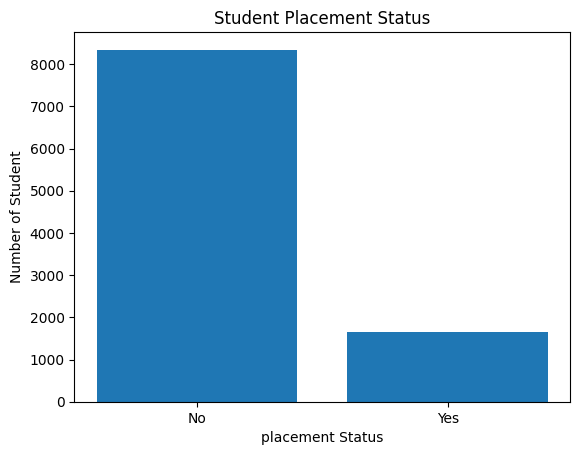

In [47]:
import matplotlib.pyplot as plt

placement_count = df["Placement"].value_counts()

plt.bar(
  placement_count.index,
  placement_count.values
)

plt.xlabel("placement Status")
plt.ylabel("Number of Student")
plt.title("Student Placement Status")

plt.savefig("static/placement_status.png")

plt.show()

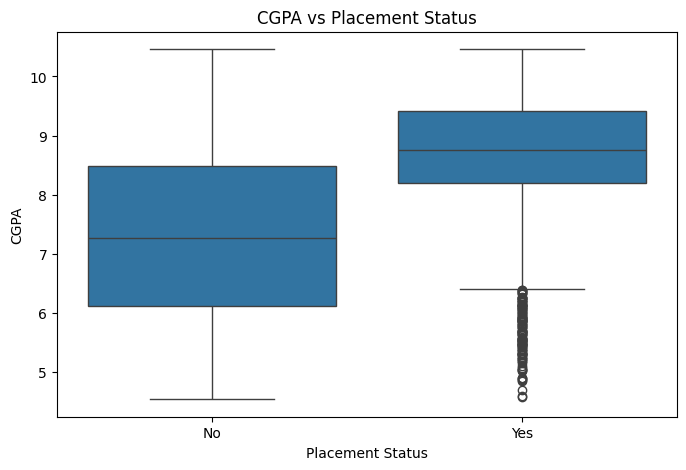

In [48]:
import seaborn as sns

plt.figure(figsize=(8,5))

sns.boxplot(
  x="Placement",
  y="CGPA",
  data=df
)

plt.xlabel("Placement Status")
plt.ylabel("CGPA")
plt.title("CGPA vs Placement Status")

plt.savefig("static/cgpa_placement.png")

plt.show()


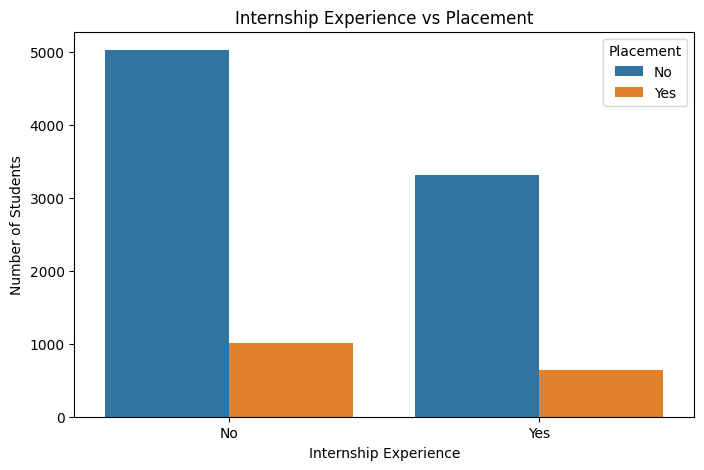

In [49]:
plt.figure(figsize=(8,5))

sns.countplot(
  data=df,
  x="Internship_Experience",
  hue="Placement"
)

plt.xlabel("Internship Experience")
plt.ylabel("Number of Students")
plt.title("Internship Experience vs Placement")

plt.savefig("static/internship_placement.png")

plt.show()

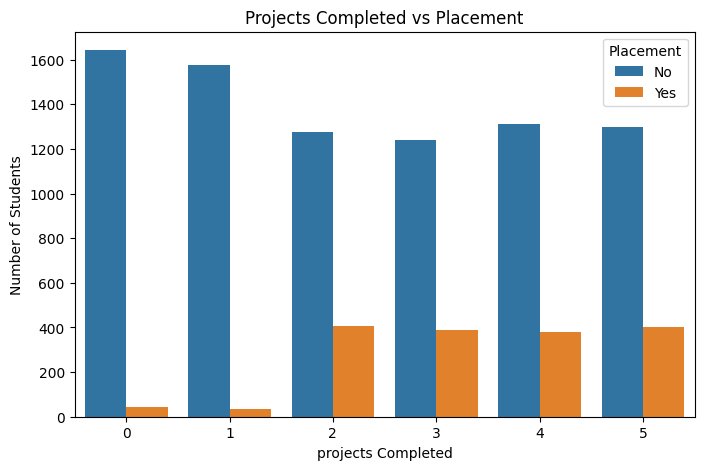

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(
  data=df,
  x="Projects_Completed",
  hue="Placement"
)

plt.xlabel("projects Completed")
plt.ylabel("Number of Students")
plt.title("Projects Completed vs Placement")

plt.savefig("static/projects_placement.png")

plt.show()

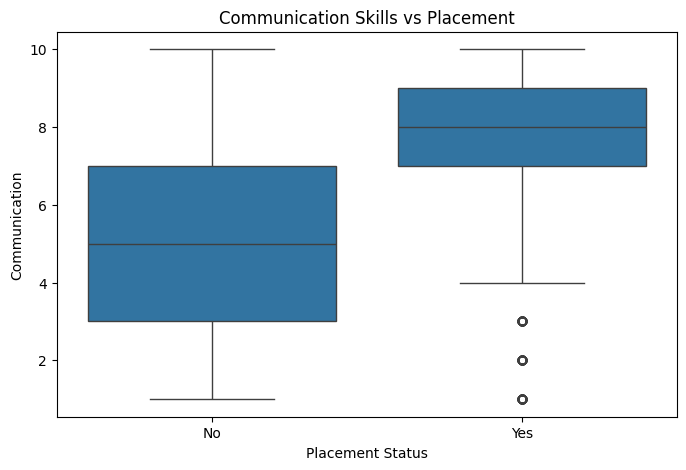

In [51]:
plt.figure(figsize=(8,5))

sns.boxplot(
  data=df,
  x="Placement",
  y="Communication_Skills"
)

plt.xlabel("Placement Status")
plt.ylabel("Communication")
plt.title("Communication Skills vs Placement")

plt.savefig("static/communication_placement.png")

plt.show()

### SQL DATABASE

In [52]:
import sqlite3

In [53]:
conn = sqlite3.connect("students.db")

df.to_sql(
  "students",
  conn,
  if_exists="replace",
  index=False
)
conn.close()

print("\nData successfully stored in SQL database.")


Data successfully stored in SQL database.


In [54]:
conn = sqlite3.connect("students.db")

query =""" 
SELECT *
FROM students
"""
result = pd.read_sql_query(query, conn)

print("\nStudents data from SQL:")
print(result.head())

conn.close()


Students data from SQL:
  College_ID   IQ  Prev_Sem_Result  CGPA  Academic_Performance  \
0    CLG0030  107             6.61  6.28                     8   
1    CLG0061   97             5.52  5.37                     8   
2    CLG0036  109             5.36  5.83                     9   
3    CLG0055  122             5.47  5.75                     6   
4    CLG0004   96             7.91  7.69                     7   

  Internship_Experience  Extra_Curricular_Score  Communication_Skills  \
0                    No                       8                     8   
1                    No                       7                     8   
2                    No                       3                     1   
3                   Yes                       1                     6   
4                    No                       8                    10   

   Projects_Completed Placement  
0                   4        No  
1                   0        No  
2                   1        No  
3  

In [55]:
conn = sqlite3.connect("students.db")

query =""" 
SELECT *
FROM students
WHERE Placement = 'Yes'
"""

placed_students = pd.read_sql_query(
  query,
  conn
)
print("\nPlaced Students:")
print(placed_students.head())


Placed Students:
  College_ID   IQ  Prev_Sem_Result  CGPA  Academic_Performance  \
0    CLG0071  123             6.68  6.58                     5   
1    CLG0096  111             8.77  8.76                     7   
2    CLG0068   86             8.20  8.15                     7   
3    CLG0072  121             8.41  8.07                     5   
4    CLG0087   78             8.67  9.17                     7   

  Internship_Experience  Extra_Curricular_Score  Communication_Skills  \
0                    No                       7                     8   
1                    No                       3                     1   
2                    No                       8                     9   
3                   Yes                       1                     3   
4                   Yes                      10                    10   

   Projects_Completed Placement  
0                   2       Yes  
1                   2       Yes  
2                   4       Yes  
3         

In [56]:
conn = sqlite3.connect("students.db")

query =""" 
SELECT AVG(CGPA) AS average_cgpa
FROM students
WHERE Placement = 'Yes' 
"""

print("\nAverage CGPA of Placed Students:")
print(result)


Average CGPA of Placed Students:
     College_ID   IQ  Prev_Sem_Result  CGPA  Academic_Performance  \
0       CLG0030  107             6.61  6.28                     8   
1       CLG0061   97             5.52  5.37                     8   
2       CLG0036  109             5.36  5.83                     9   
3       CLG0055  122             5.47  5.75                     6   
4       CLG0004   96             7.91  7.69                     7   
...         ...  ...              ...   ...                   ...   
9995    CLG0021  119             8.41  8.29                     4   
9996    CLG0098   70             9.25  9.34                     7   
9997    CLG0066   89             6.08  6.25                     3   
9998    CLG0045  107             8.77  8.92                     3   
9999    CLG0060  109             9.41  9.77                     8   

     Internship_Experience  Extra_Curricular_Score  Communication_Skills  \
0                       No                       8           

In [59]:
conn = sqlite3.connect("students.db")

query = """
SELECT
    Placement,
    COUNT(*) AS student_count
FROM students
GROUP BY Placement
"""

result = pd.read_sql_query(query, conn)

print("\nPlacement-wise Student Count:")
print(result)

conn.close()




Placement-wise Student Count:
  Placement  student_count
0        No           8341
1       Yes           1659


In [60]:
conn = sqlite3.connect("students.db")

query = """
SELECT
    Internship_Experience,
    Placement,
    COUNT(*) AS student_count
FROM students
GROUP BY Internship_Experience, Placement
ORDER BY Internship_Experience, Placement
"""

result = pd.read_sql_query(query, conn)

print("\nInternship Experience vs Placement:")
print(result)

conn.close()


Internship Experience vs Placement:
  Internship_Experience Placement  student_count
0                    No        No           5024
1                    No       Yes           1012
2                   Yes        No           3317
3                   Yes       Yes            647


In [61]:
conn = sqlite3.connect("students.db")

query = """
SELECT
    Projects_Completed,
    Placement,
    COUNT(*) AS student_count
FROM students
GROUP BY Projects_Completed, Placement
ORDER BY Projects_Completed, Placement
"""

result = pd.read_sql_query(query, conn)

print("\nProjects Completed vs Placement:")
print(result)

conn.close()


Projects Completed vs Placement:
    Projects_Completed Placement  student_count
0                    0        No           1643
1                    0       Yes             45
2                    1        No           1576
3                    1       Yes             33
4                    2        No           1274
5                    2       Yes            407
6                    3        No           1238
7                    3       Yes            389
8                    4        No           1312
9                    4       Yes            381
10                   5        No           1298
11                   5       Yes            404


In [62]:
conn = sqlite3.connect("students.db")

query = """
SELECT
    Placement,
    AVG(Communication_Skills) AS average_communication
FROM students
GROUP BY Placement
"""

result = pd.read_sql_query(query, conn)

print("\nAverage Communication Skills by Placement:")
print(result)

conn.close()


Average Communication Skills by Placement:
  Placement  average_communication
0        No               5.143748
1       Yes               7.663653


In [63]:
conn = sqlite3.connect("students.db")

query = """
SELECT
    College_ID,
    CGPA,
    Internship_Experience,
    Projects_Completed,
    Communication_Skills,
    Placement
FROM students
WHERE CGPA >= 8
AND Internship_Experience = 'Yes'
AND Placement = 'Yes'
"""

result = pd.read_sql_query(query, conn)

print("\nStudents with CGPA >= 8, Internship and Placement:")
print(result.head(10))

print("\nTotal Students:")
print(len(result))

conn.close()


Students with CGPA >= 8, Internship and Placement:
  College_ID  CGPA Internship_Experience  Projects_Completed  \
0    CLG0072  8.07                   Yes                   3   
1    CLG0087  9.17                   Yes                   2   
2    CLG0073  9.01                   Yes                   4   
3    CLG0001  8.73                   Yes                   2   
4    CLG0066  9.39                   Yes                   4   
5    CLG0026  8.23                   Yes                   2   
6    CLG0054  8.52                   Yes                   0   
7    CLG0027  8.50                   Yes                   3   
8    CLG0085  8.97                   Yes                   3   
9    CLG0042  9.21                   Yes                   5   

   Communication_Skills Placement  
0                     3       Yes  
1                    10       Yes  
2                     9       Yes  
3                     6       Yes  
4                    10       Yes  
5                     8    

In [64]:
conn = sqlite3.connect("students.db")

query = """
SELECT
    College_ID,
    CGPA,
    IQ,
    Academic_Performance,
    Projects_Completed,
    Communication_Skills,
    Placement
FROM students
ORDER BY CGPA DESC
LIMIT 10
"""

result = pd.read_sql_query(query, conn)

print("\nTop 10 Students by CGPA:")
print(result)

conn.close()


Top 10 Students by CGPA:
  College_ID   CGPA   IQ  Academic_Performance  Projects_Completed  \
0    CLG0027  10.46   79                     1                   5   
1    CLG0076  10.46   82                     1                   1   
2    CLG0072  10.45   82                     4                   0   
3    CLG0065  10.45   73                     6                   1   
4    CLG0010  10.44   91                     7                   5   
5    CLG0054  10.42  109                    10                   0   
6    CLG0089  10.42   87                    10                   3   
7    CLG0059  10.41   73                     1                   4   
8    CLG0044  10.40   92                     3                   1   
9    CLG0067  10.40   97                     3                   5   

   Communication_Skills Placement  
0                     9       Yes  
1                     7        No  
2                     4        No  
3                     8        No  
4                     3

In [65]:
conn = sqlite3.connect("students.db")

query = """
SELECT
    COUNT(*) AS total_students,
    SUM(CASE WHEN Placement = 'Yes' THEN 1 ELSE 0 END) AS placed_students,
    ROUND(
        100.0 * SUM(CASE WHEN Placement = 'Yes' THEN 1 ELSE 0 END) / COUNT(*),
        2
    ) AS placement_rate
FROM students
"""

result = pd.read_sql_query(query, conn)

print("\nOverall Placement Statistics:")
print(result)

conn.close()


Overall Placement Statistics:
   total_students  placed_students  placement_rate
0           10000             1659           16.59


In [66]:
conn = sqlite3.connect("students.db")

query = """
SELECT
    Academic_Performance,
    Placement,
    COUNT(*) AS student_count
FROM students
GROUP BY Academic_Performance, Placement
ORDER BY Academic_Performance, Placement
"""

result = pd.read_sql_query(query, conn)

print("\nAcademic Performance vs Placement:")
print(result)

conn.close()


Academic Performance vs Placement:
    Academic_Performance Placement  student_count
0                      1        No            793
1                      1       Yes            170
2                      2        No            828
3                      2       Yes            167
4                      3        No            816
5                      3       Yes            175
6                      4        No            816
7                      4       Yes            188
8                      5        No            817
9                      5       Yes            157
10                     6        No            843
11                     6       Yes            147
12                     7        No            878
13                     7       Yes            149
14                     8        No            852
15                     8       Yes            173
16                     9        No            824
17                     9       Yes            163
18            

In [67]:
conn = sqlite3.connect("students.db")

query = """
SELECT
    Placement,
    AVG(Academic_Performance) AS average_academic_performance
FROM students
GROUP BY Placement
"""

result = pd.read_sql_query(query, conn)

print("\nAverage Academic Performance by Placement:")
print(result)

conn.close()


Average Academic Performance by Placement:
  Placement  average_academic_performance
0        No                      5.565520
1       Yes                      5.450271


In [68]:
conn = sqlite3.connect("students.db")

query = """
SELECT
    Internship_Experience,
    Projects_Completed,
    Placement,
    COUNT(*) AS student_count
FROM students
GROUP BY Internship_Experience, Projects_Completed, Placement
ORDER BY Internship_Experience, Projects_Completed, Placement
"""

result = pd.read_sql_query(query, conn)

print("\nInternship + Projects vs Placement:")
print(result)

conn.close()


Internship + Projects vs Placement:
   Internship_Experience  Projects_Completed Placement  student_count
0                     No                   0        No            986
1                     No                   0       Yes             26
2                     No                   1        No            945
3                     No                   1       Yes             19
4                     No                   2        No            771
5                     No                   2       Yes            229
6                     No                   3        No            737
7                     No                   3       Yes            245
8                     No                   4        No            795
9                     No                   4       Yes            248
10                    No                   5        No            790
11                    No                   5       Yes            245
12                   Yes                   0        N